In [16]:
import os
import sys
notebook_path = os.getcwd()
sys.path.insert(0, os.path.dirname(notebook_path))
import numpy as np
import torch
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import k_hop_subgraph, to_networkx
from torch_geometric.data import Data
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.typing import Adj
import itertools
from torch_geometric.utils import (
    degree,
    is_sparse,
    scatter,
    sort_edge_index,
    to_edge_index,
    from_networkx,
    to_networkx,
    train_test_split_edges,
    to_undirected
)
from torch_geometric.data import Data


from syn_real.custom_wl import (get_graph_orbits,
                                run_wl_test_and_group_nodes)
from syn_real.plotting import plot_graph_with_orbits
from syn_real.measure import (hash_links_by_orbit, 
                              compute_automorphism_metrics,
                              count_automorphic_edges
                            )
from syn_real.auto_operation import (create_disjoint_graph,
                            add_random_edges)
from collections import Counter

In [17]:

def get_k_hop_subgraph_from_dataset(dataset_name="Cora", num_hops=4, node_idx=0, visualize=True):
    """
    Load a dataset and extract a k-hop subgraph around a given node.
    
    Args:
        dataset_name (str): e.g. "Cora", "Citeseer", "PubMed"
        num_hops (int): Number of hops to include in the subgraph
        node_idx (int): Center node to extract from
        visualize (bool): If True, visualize the subgraph

    Returns:
        Data: PyG Data object of the subgraph
    """
    # Load dataset
    dataset = Planetoid(root=f'/tmp/{dataset_name}', name=dataset_name)
    data = dataset[0]

    # Extract k-hop subgraph
    subset, sub_edge_index, mapping, edge_mask = k_hop_subgraph(
        node_idx=node_idx,
        num_hops=num_hops,
        edge_index=data.edge_index,
        relabel_nodes=True,
        num_nodes=data.num_nodes
    )

    # Create subgraph Data object
    sub_x = data.x[subset]
    sub_y = data.y[subset]
    sub_data = Data(x=sub_x, edge_index=sub_edge_index, y=sub_y)

    # Optional visualization
    if visualize:
        G_sub = to_networkx(sub_data, to_undirected=True)
        plt.figure(figsize=(8, 6))
        nx.draw(G_sub, with_labels=True, node_size=300, node_color='skyblue', edge_color='gray')
        plt.title(f"{num_hops}-Hop Subgraph from Node {node_idx} ({dataset_name})")
        plt.axis('off')
        plt.show()

    return sub_data



def plot_orbit_dist(node_groups):
    node_dist = {}
    for node, label in enumerate(node_groups):
        if label not in node_dist:
            node_dist[label] = []
        node_dist[label].append(node)
        
    group_sizes = np.array([len(group) for group in node_dist.values()])
    

    plt.figure(figsize=(6, 4))
    plt.hist(group_sizes, bins=range(min(group_sizes), max(group_sizes) + 2), align='left', rwidth=0.8)
    plt.xlabel('Orbit Label')
    plt.ylabel('Frequency')
    plt.title('Histogram of Orbit Size (Dist of Dist)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    # plt.savefig(f"{name}_distribution_d{depth}.pdf")
    plt.close()



def plot_orbit(orbits):
    plt.figure(figsize=(6, 4))
    plt.hist(orbits, bins=range(min(orbits), max(orbits) + 2), align='left', rwidth=0.8)
    plt.xlabel('Orbit Label')
    plt.ylabel('Frequency')
    plt.title('Orbit Distribution')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    # plt.savefig(f"{name}_distribution_d{depth}.pdf")
    plt.close()
    

import matplotlib.pyplot as plt
import networkx as nx

def plot_combined_orbit_graph(G, pos, orbits, edge_class_counts, custom_labels=None, figsize=(18, 6), cmap='tab20b'):
    """
    Combine three plots into one figure with three subplots:
    1. Graph colored by orbit labels
    2. Orbit distribution histogram
    3. Automorphic edge distribution stem plot

    Parameters:
        G (nx.Graph): The graph to plot.
        pos (dict): Node positions.
        orbits (list or array): Orbit label for each node.
        edge_class_counts (dict): Dictionary of edge class counts.
        custom_labels (dict, optional): Dictionary of node labels.
        figsize (tuple): Figure size.
        cmap (str): Matplotlib colormap for nodes.
    """

    fig, axs = plt.subplots(1, 3, figsize=figsize)

    # 1. Graph with node colors by orbit labels
    node_colors = [orbits[node] for node in G.nodes()]
    nx.draw(
        G,
        pos=pos,
        labels=custom_labels,
        node_color=node_colors,
        cmap=cmap,
        node_size=500,
        font_weight='bold',
        edgecolors='black',
        ax=axs[0]
    )
    axs[0].set_title("Graph Colored by Orbit Labels")

    # 2. Orbit distribution histogram
    axs[1].hist(orbits, bins=range(min(orbits), max(orbits) + 2), align='left', rwidth=0.8)
    axs[1].set_xlabel('Orbit Label')
    axs[1].set_ylabel('Frequency')
    axs[1].set_title('Orbit Distribution')
    axs[1].grid(axis='y', linestyle='--', alpha=0.7)

    # 3. Automorphic edge distribution stem plot
    unique_orbit_seq = sorted(edge_class_counts.values(), reverse=True)
    axs[2].stem(unique_orbit_seq, markerfmt='bo', basefmt=' ')
    axs[2].set_title('Automorphic Edge Distribution')
    axs[2].set_xlabel("Automorphism Edge Classes")
    axs[2].set_ylabel("Frequency")
    axs[2].grid(True, linestyle='--', alpha=0.7)

    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

    
def analyze_automorphisms(data, G):

    _, node_labels, orbits = run_wl_test_and_group_nodes(data.edge_index, num_nodes=data.num_nodes, num_iterations=100)
    orbits, num_orbit = get_graph_orbits(G)
    # print(f"Number of orbits: {num_orbit}")

    custom_labels = {}
    for i, ov in zip(G.nodes(), orbits):
            custom_labels[i] = f"{ov}"

    count_automorphic_edges(G, orbits)
    
    metrics, num_nodes, group_sizes = compute_automorphism_metrics(orbits, G.number_of_nodes())
    
    # plot_orbit_dist(orbits)
    # plot_graph_with_orbits(G, 
    #                        None, 
    #                        orbits, 
    #                        custom_labels=custom_labels, 
    #                        figsize=(8, 6), cmap='tab20b')
    # plot_orbit(orbits)
    edge_class_counts, _ = hash_links_by_orbit(G, orbits)
    from syn_real.plotting import plot_unique_edge_class
    # plot_unique_edge_class(edge_class_counts)


    plot_combined_orbit_graph(G, None, orbits, edge_class_counts, custom_labels=custom_labels)

    return metrics, num_nodes, group_sizes, orbits

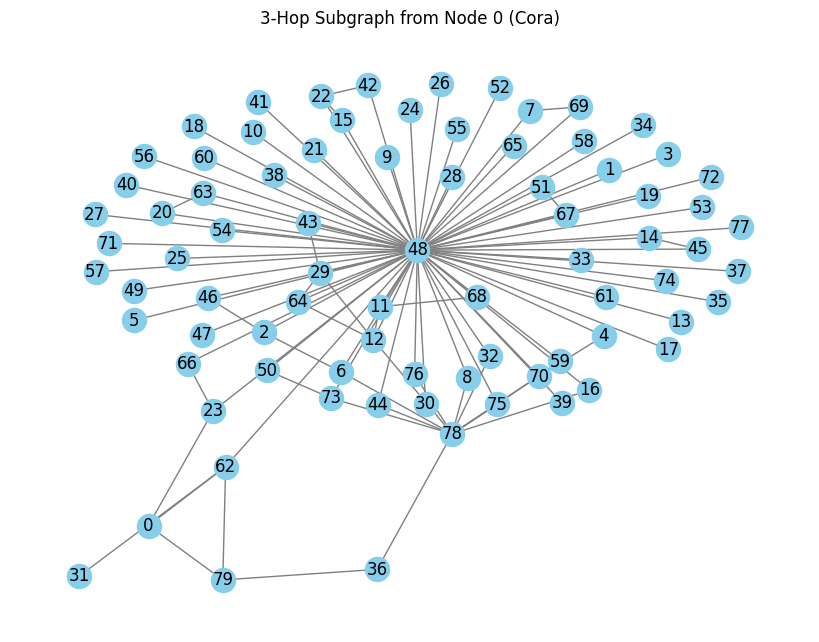

Data(x=[80, 1433], edge_index=[2, 218], y=[80])
Subgraph edge index: tensor([[23, 62, 79, 48,  6, 46, 48, 48, 48, 70, 48,  2, 48, 78, 48, 69, 48, 78,
         48, 48, 12, 48, 68, 11, 29, 48, 64, 78, 48, 45, 48, 22, 48, 48, 78, 48,
         48, 48, 48, 63, 48, 15, 42, 48,  0, 48, 66, 48, 48, 48, 48, 48, 12, 43,
         48, 64, 48, 62, 48, 78, 48, 48, 48, 78, 79, 48, 48, 48, 48, 48, 22, 48,
         29, 48, 48, 78, 14, 48,  2, 48, 48,  1,  2,  3,  4,  5,  6,  7,  8,  9,
         10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27,
         28, 29, 30, 32, 33, 34, 35, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47,
         49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66,
         67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 48, 48, 73, 48, 67, 48, 48,
         48, 48, 48, 48, 48, 48, 78, 48, 48,  0, 31, 48, 79, 20, 48, 12, 29, 48,
         48, 23, 48, 48, 51, 11, 48,  7, 48,  4, 48, 78, 48, 48, 48, 50, 78, 48,
         48, 78, 48, 78, 48,  6,  8, 12,

In [18]:
import random

def rewire_edges_regularly(data, keep_prob=0.7):
    edge_list = data.edge_index.T.tolist()
    num_edges = len(edge_list)
    new_edges = []
    for _ in range(num_edges):
        if random.random() < keep_prob:
            new_edges.append(random.choice(edge_list))
        else:
            u, v = random.sample(range(data.num_nodes), 2)
            new_edges.append([u, v])
    new_edge_index = torch.tensor(new_edges, dtype=torch.long).T
    return Data(edge_index=new_edge_index, num_nodes=data.num_nodes, x=data.x)


if __name__ == '__main__':

    # Example usage
    subgraph = get_k_hop_subgraph_from_dataset(dataset_name="Cora", num_hops=3, node_idx=0, visualize=True)
    print(subgraph)
    print("Subgraph edge index:", subgraph.edge_index)
    print("Subgraph node features:", subgraph.x.shape)
    print("Subgraph labels:", subgraph.y.shape)

Number of nodes in the graph: 80
Intra-orbit edges: 1725, Inter-orbit edges: 4314
Non-distinguishable edges: 6039


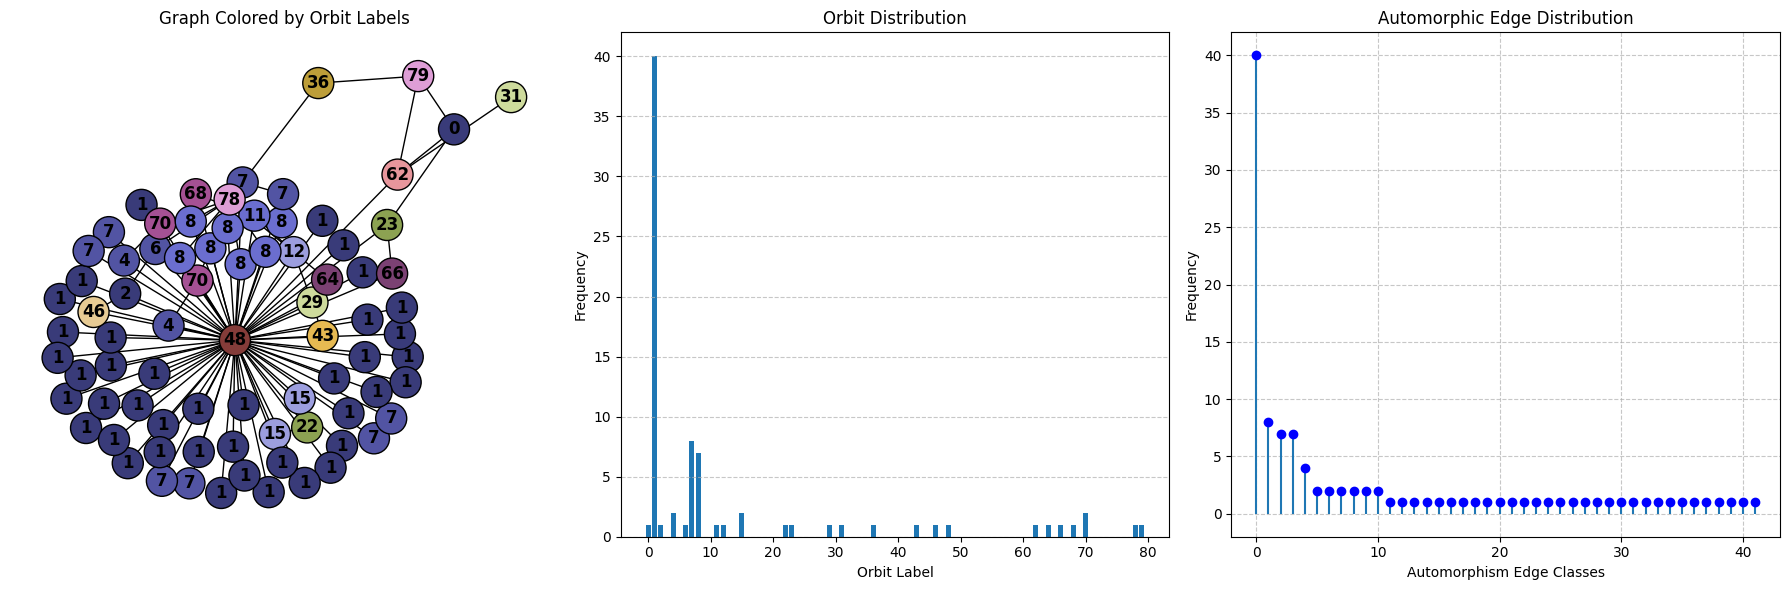

None
Intra-orbit edges: 6976, Inter-orbit edges: 18624
Non-distinguishable edges: 25600


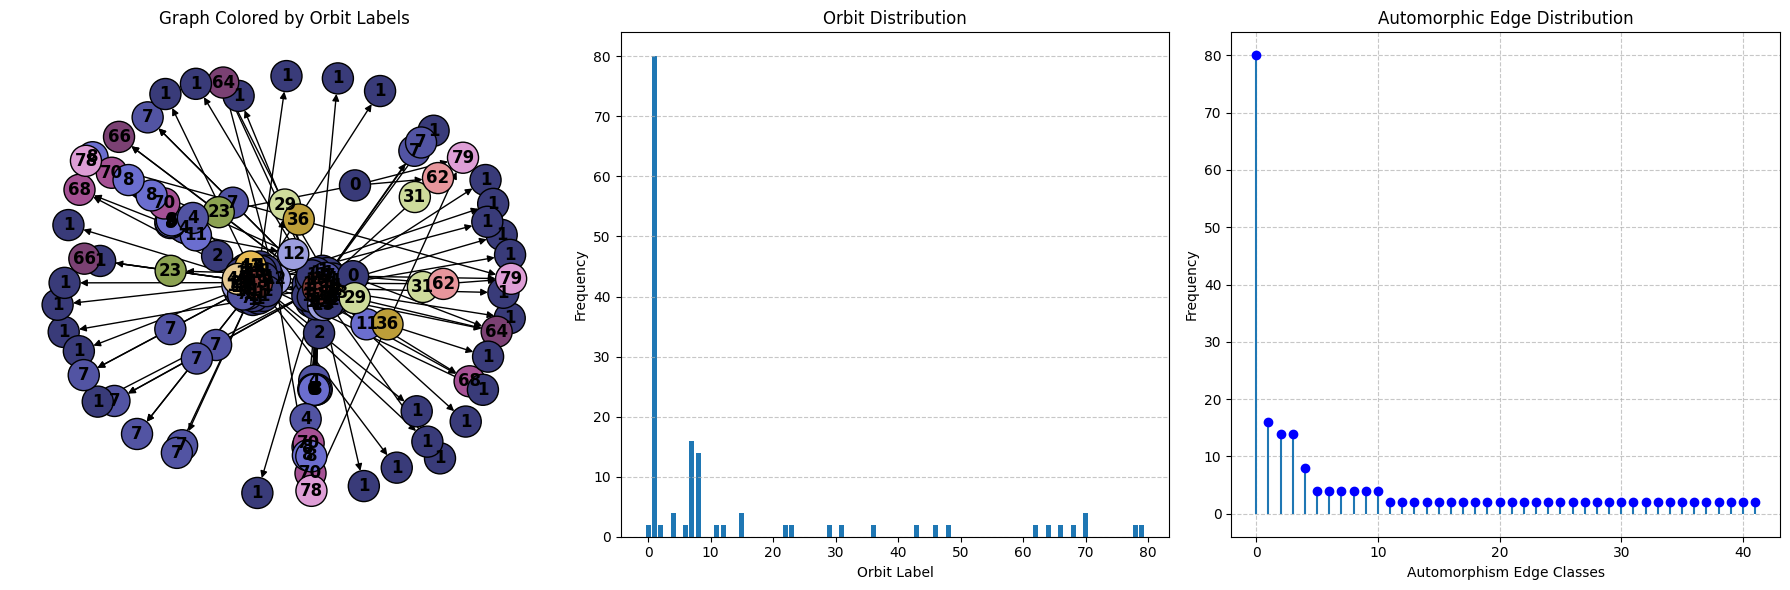

({'Automorphism Ratio (A_r1)': np.float64(0.2725),
  'A_r_norm_2': np.float64(0.8719140750434635),
  'A_r_norm_1': np.float64(0.7438281500869269),
  'Number of Unique Groups (C_auto)': 25,
  'Automorphism Ratio (A_r_log)': np.float64(-0.2561718499130729),
  'num_nodes': 160,
  'automorphism_score': 0.15625},
 160,
 array([ 2, 80,  2,  4,  2, 16, 14,  2,  2,  4,  2,  2,  2,  2,  2,  2,  2,
         2,  2,  2,  2,  2,  4,  2,  2]),
 [0,
  1,
  2,
  1,
  4,
  1,
  6,
  7,
  8,
  1,
  1,
  11,
  12,
  1,
  7,
  15,
  8,
  1,
  1,
  1,
  7,
  1,
  22,
  23,
  1,
  1,
  1,
  1,
  1,
  29,
  1,
  31,
  8,
  1,
  1,
  1,
  36,
  1,
  1,
  1,
  1,
  1,
  15,
  43,
  8,
  7,
  46,
  1,
  48,
  1,
  4,
  7,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  8,
  1,
  1,
  62,
  7,
  64,
  1,
  66,
  7,
  68,
  7,
  70,
  1,
  1,
  70,
  1,
  8,
  8,
  1,
  78,
  79,
  0,
  1,
  2,
  1,
  4,
  1,
  6,
  7,
  8,
  1,
  1,
  11,
  12,
  1,
  7,
  15,
  8,
  1,
  1,
  1,
  7,
  1,
  22,
  23,
  1,
  1,
  1,
  1,
 

In [19]:
G = to_networkx(subgraph, to_undirected=True)

# Process Graph with WL Test
data = from_networkx(G)
print(f"Number of nodes in the graph: {data.num_nodes}")
analyze_automorphisms(data,G)
data = create_disjoint_graph(data)
G = to_networkx(data)
analyze_automorphisms(data,G)
# mdata, mG = create_disjoint_graph(data)


Intra-orbit edges: 2729, Inter-orbit edges: 20270
Non-distinguishable edges: 22999


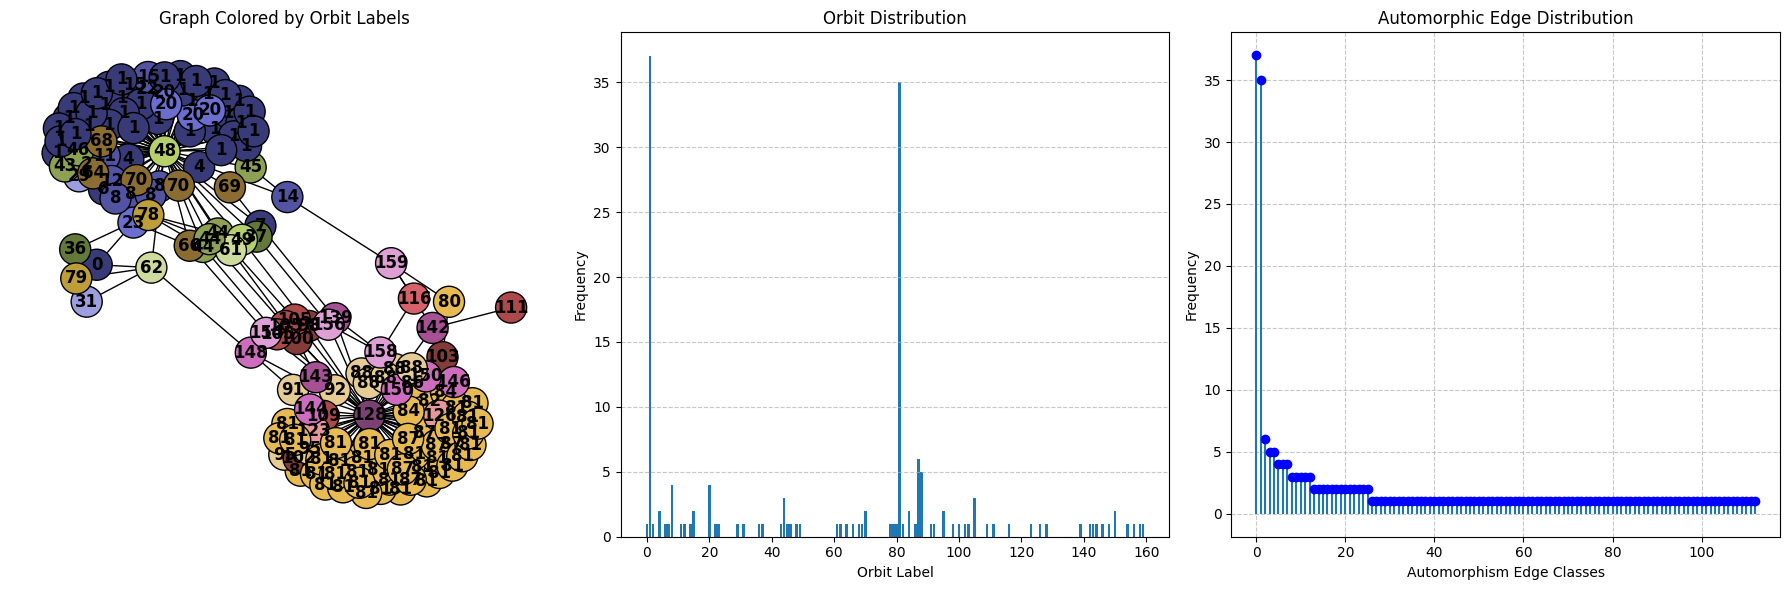

Intra-orbit edges: 1971, Inter-orbit edges: 19140
Non-distinguishable edges: 21111


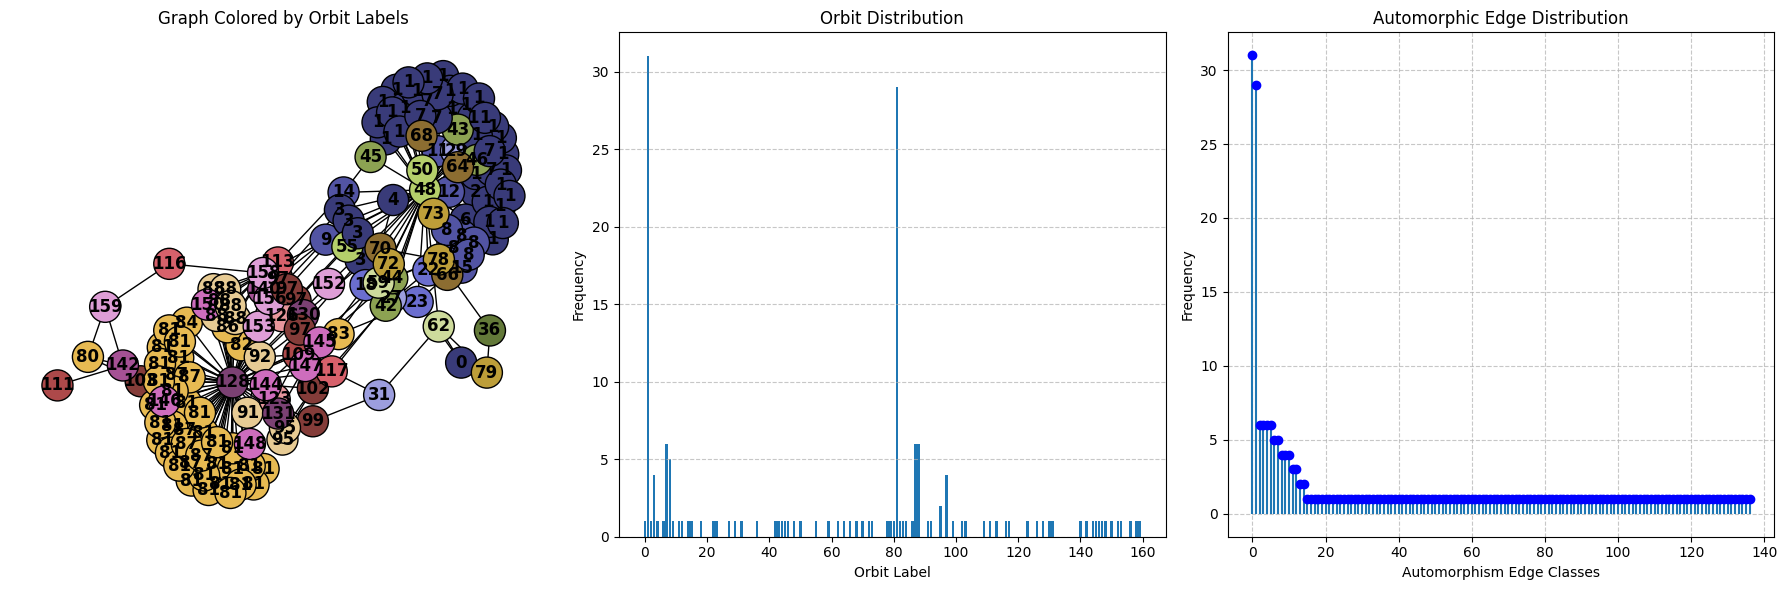

Intra-orbit edges: 1523, Inter-orbit edges: 18148
Non-distinguishable edges: 19671


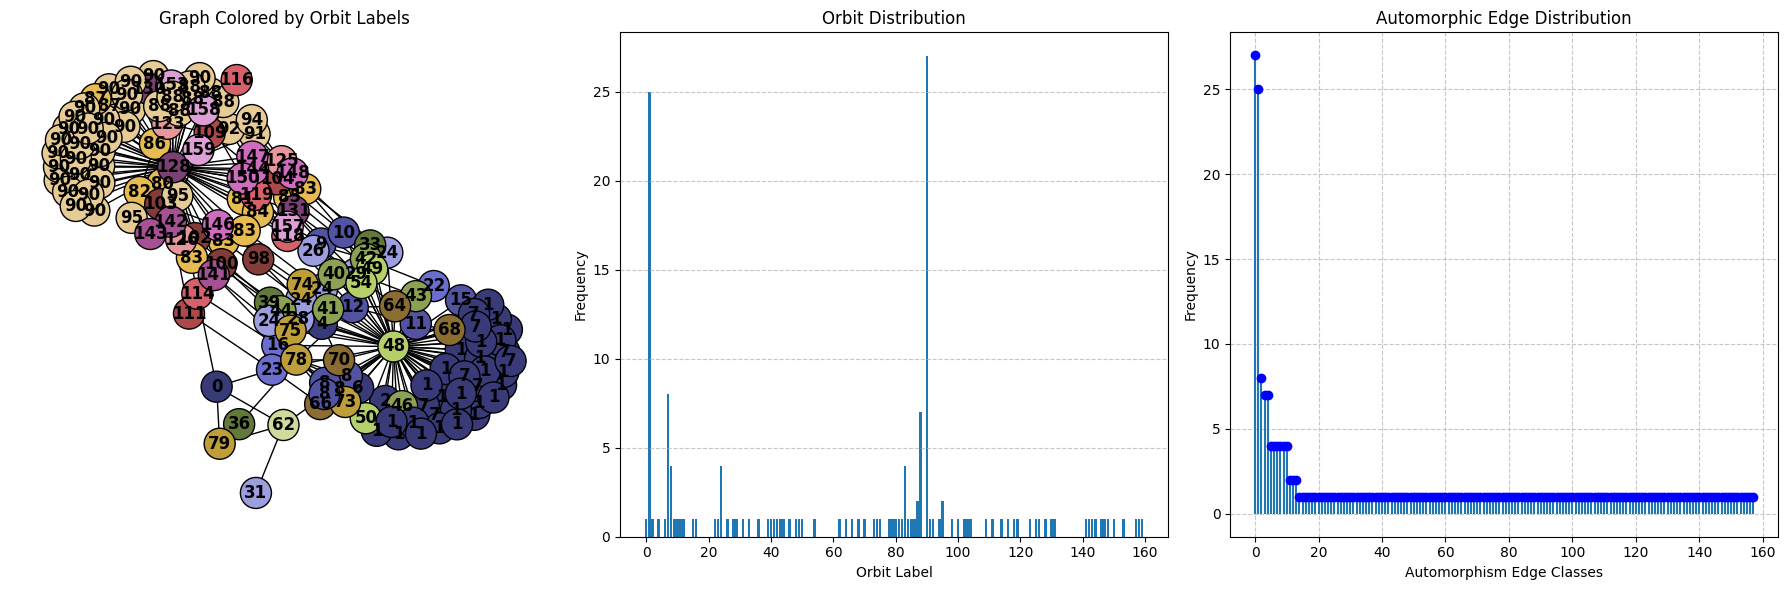

Intra-orbit edges: 1356, Inter-orbit edges: 16848
Non-distinguishable edges: 18204


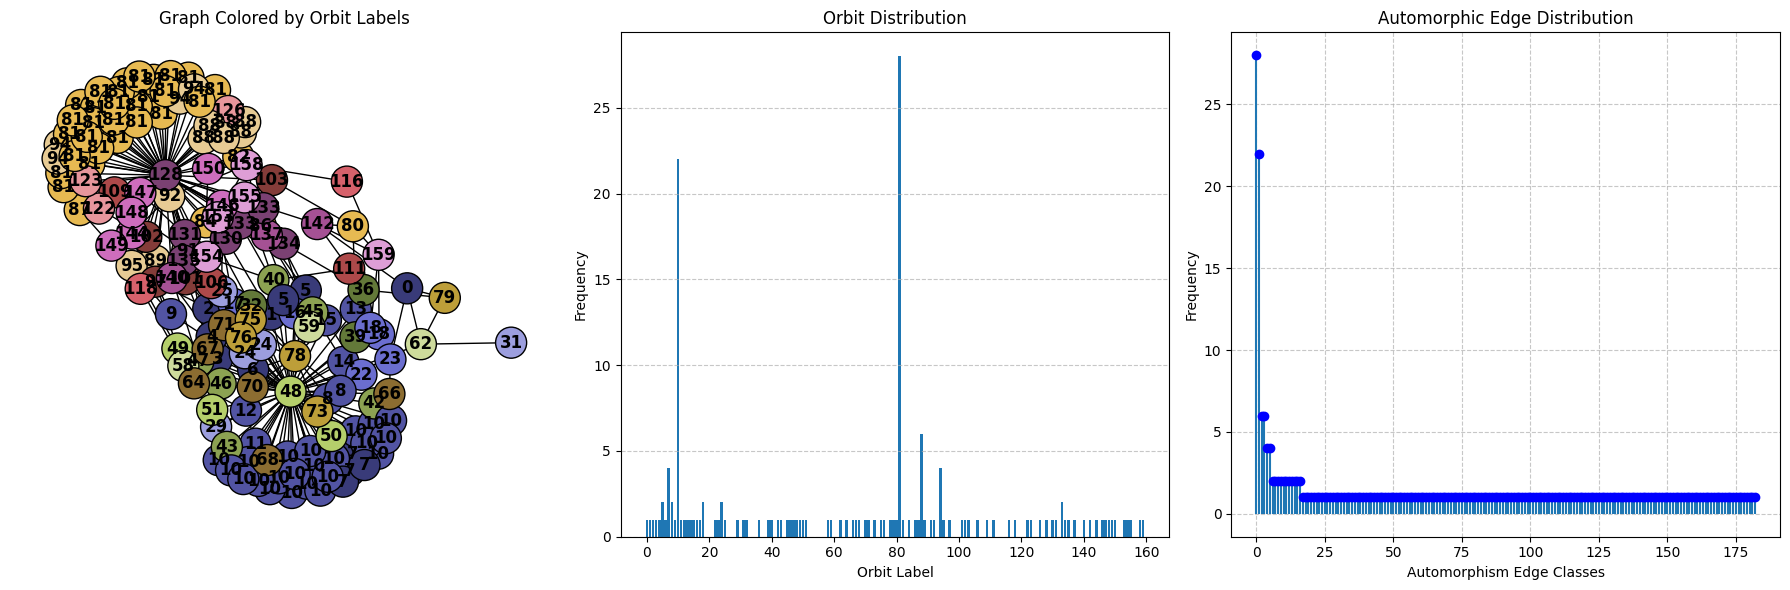

Intra-orbit edges: 1214, Inter-orbit edges: 17330
Non-distinguishable edges: 18544


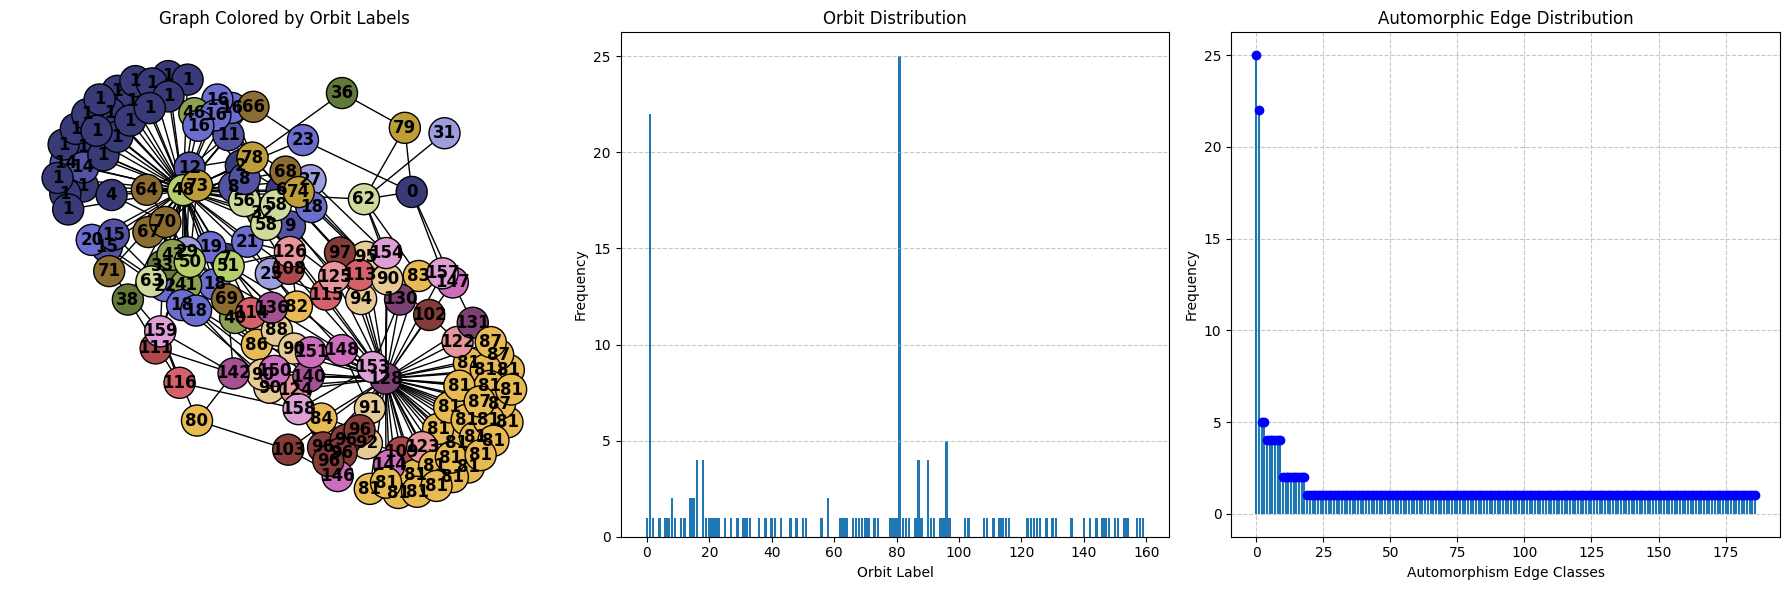

Intra-orbit edges: 1021, Inter-orbit edges: 17354
Non-distinguishable edges: 18375


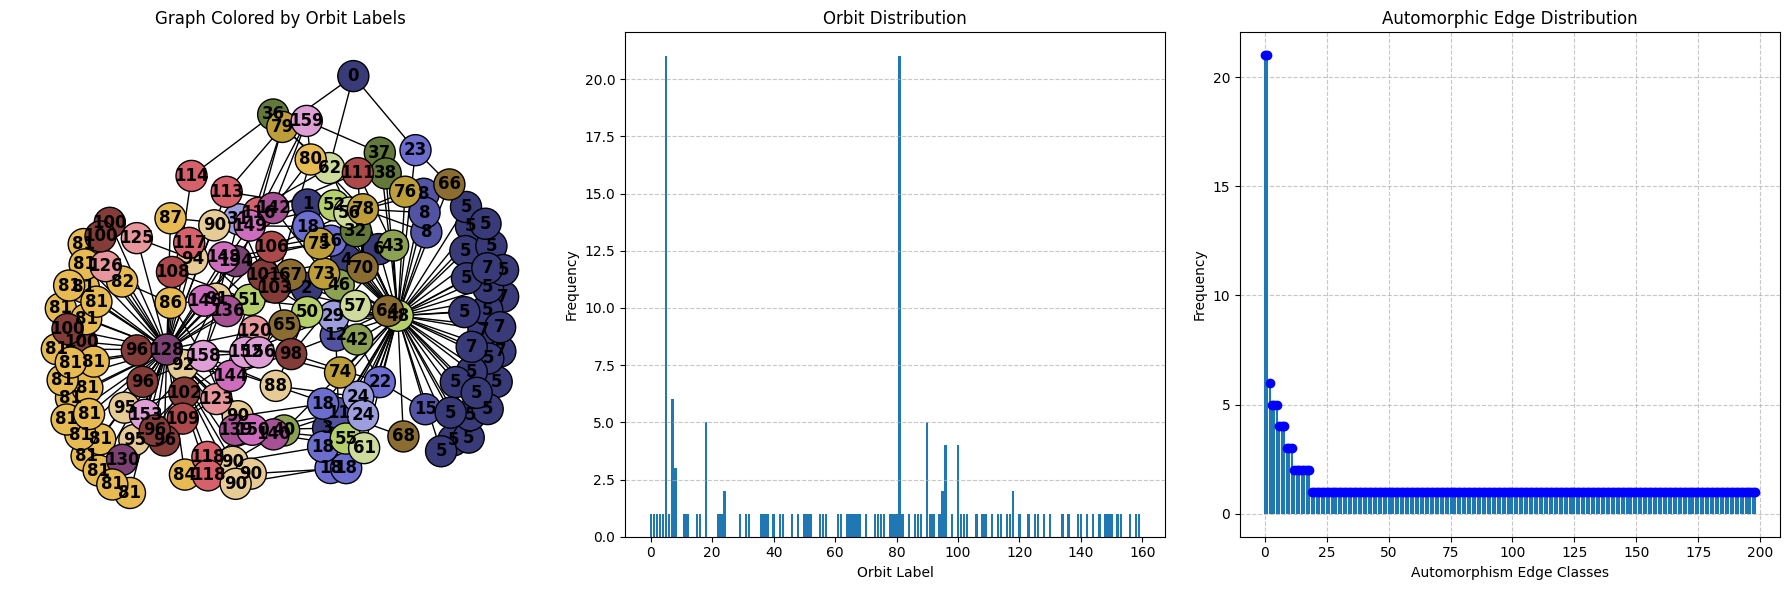

Intra-orbit edges: 579, Inter-orbit edges: 12700
Non-distinguishable edges: 13279


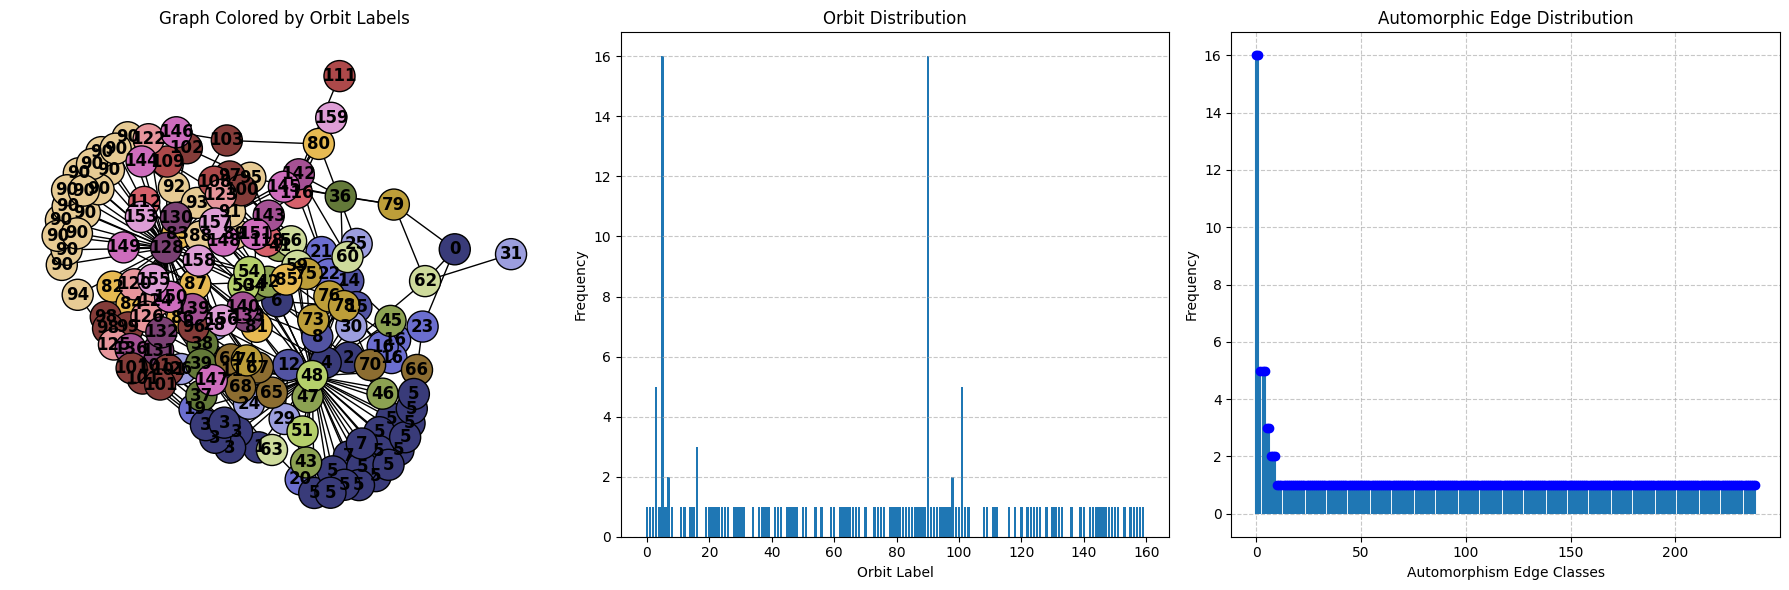

Intra-orbit edges: 451, Inter-orbit edges: 10988
Non-distinguishable edges: 11439


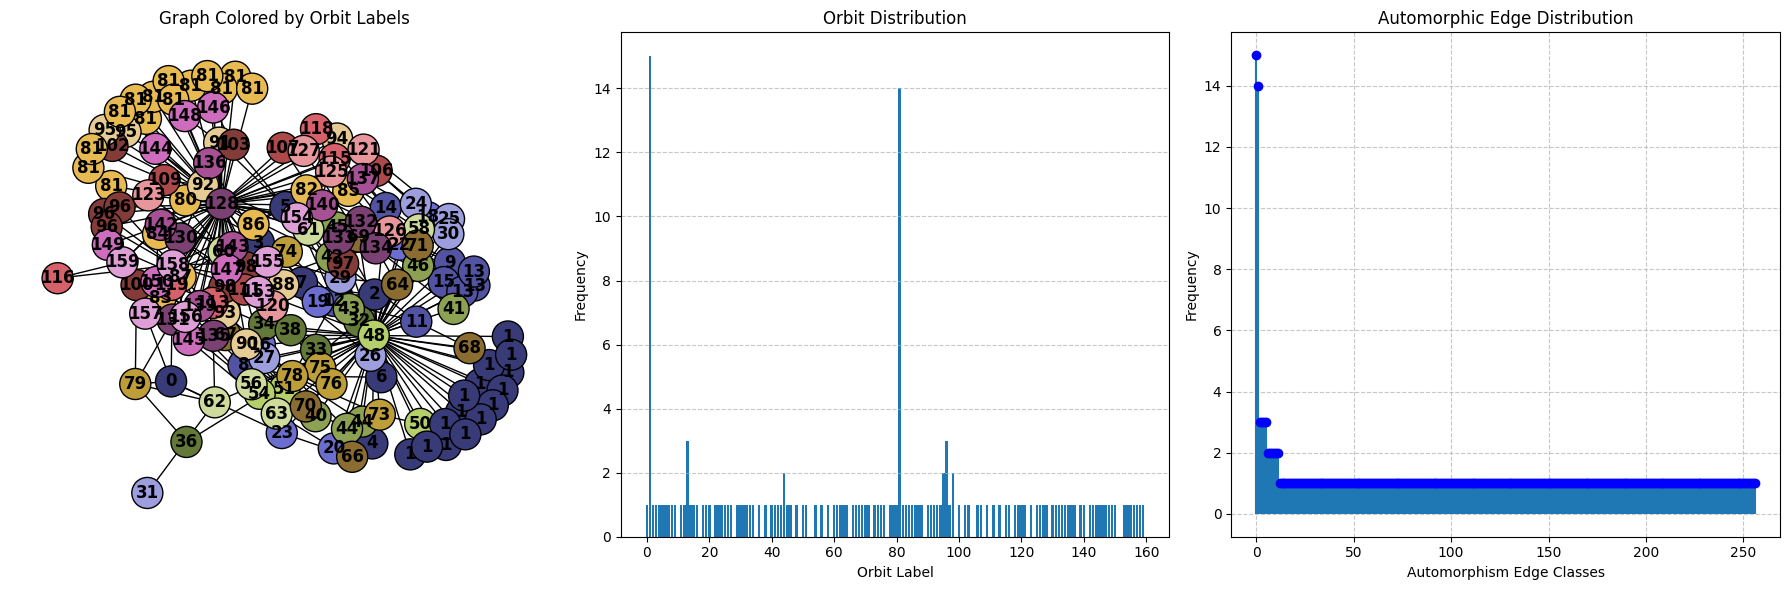

Intra-orbit edges: 329, Inter-orbit edges: 9142
Non-distinguishable edges: 9471


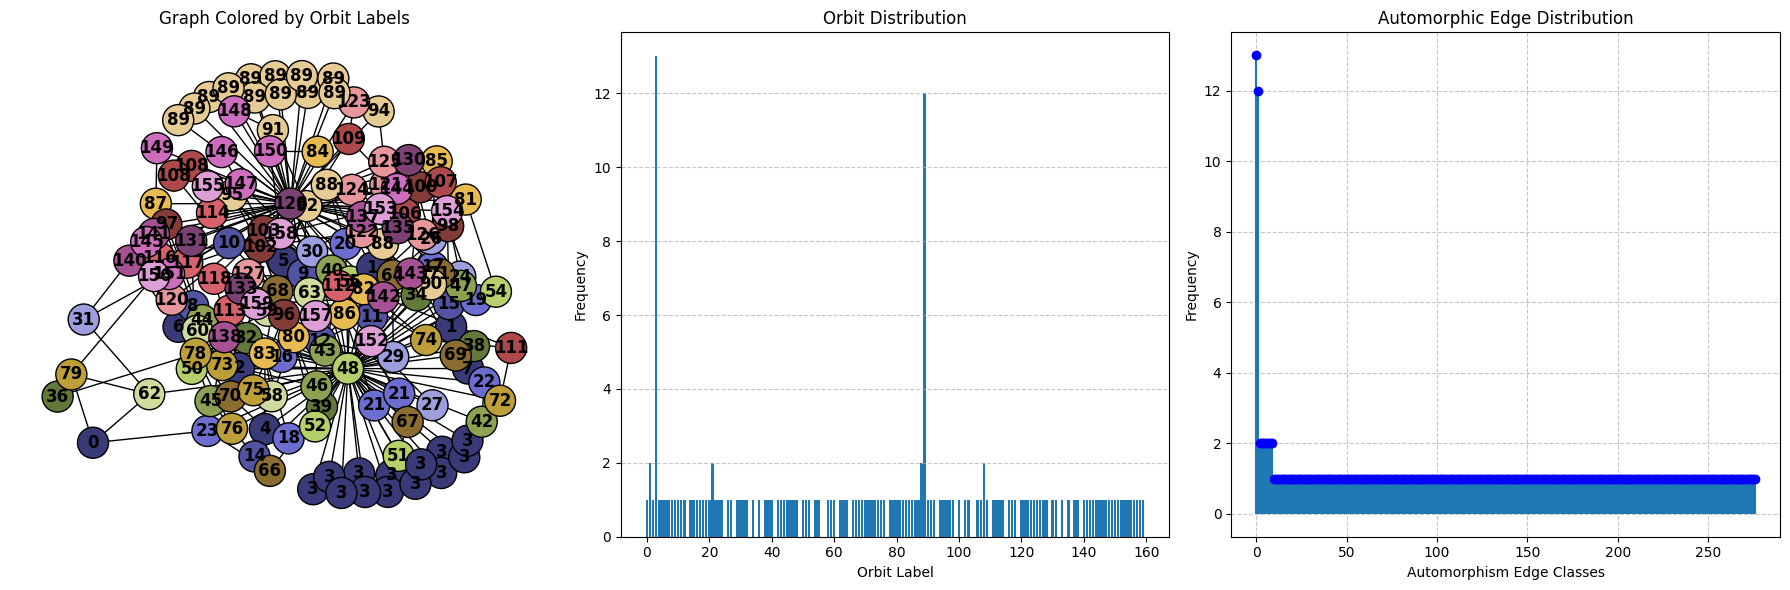

Intra-orbit edges: 285, Inter-orbit edges: 9186
Non-distinguishable edges: 9471


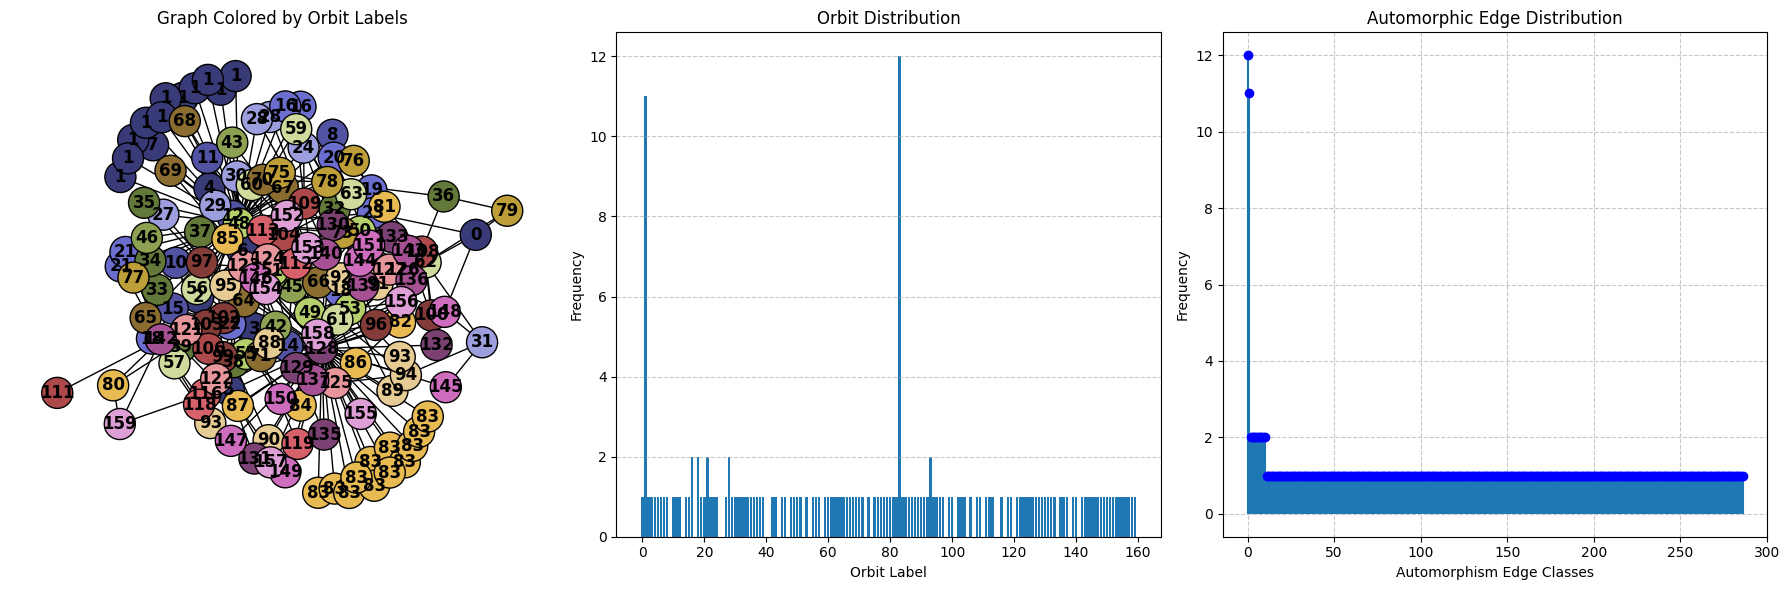

In [20]:
inter_ratio = 1
intra_ratio = 1
total_edges = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
interval = 1
for edges in total_edges:
    if inter_ratio != 0 and intra_ratio != 0 and total_edges != 0:
        updated_graph_data = add_random_edges(data, inter_ratio=inter_ratio, total_edges=edges*interval*10)
        # rewired_data = rewire_edges_regularly(data, keep_prob=0.6)
    else:
        updated_graph_data = data
    
    G = to_networkx(updated_graph_data, to_undirected=True)
    analyze_automorphisms(updated_graph_data, G)